In [2]:
# reading the output of zeroed-out interaction inference

import uproot
import os
import sys
import numpy as np
import h5py
import matplotlib.pyplot as plt

In [3]:
arrays = {}

In [ ]:
print(f'Current directory: {os.getcwd()}')
for file in os.listdir('./'):
    if file.endswith('.root'):
        print(f"Reading file: {file}") 
        with uproot.open(file) as file:
            tree = file["Events"]
            for key in tree.arrays(library='np').keys():
                if key not in arrays:
                    arrays[key] = []
                arrays[key]=np.concatenate([arrays[key],tree.arrays(library='np')[key]])

print(arrays.keys())

Reading file: HToBB_inference.root
Reading file: TTBar_inference.root
dict_keys(['label_QCD', 'score_label_QCD', 'label_Hbb', 'score_label_Hbb', 'label_Hcc', 'score_label_Hcc', 'label_Hgg', 'score_label_Hgg', 'label_H4q', 'score_label_H4q', 'label_Hqql', 'score_label_Hqql', 'label_Zqq', 'score_label_Zqq', 'label_Wqq', 'score_label_Wqq', 'label_Tbqq', 'score_label_Tbqq', 'label_Tbl', 'score_label_Tbl', '_label_', 'jet_pt', 'jet_eta', 'jet_phi', 'jet_energy', 'jet_nparticles', 'jet_sdmass', 'jet_tau1', 'jet_tau2', 'jet_tau3', 'jet_tau4'])
[[5.05145431e-01 2.03474425e-02 1.78621393e-02 3.96493196e-01
  1.49007104e-02 4.31037653e-04 5.25111333e-03 8.29349458e-03
  2.71336362e-02 4.14182059e-03]
 [2.76548713e-01 5.02724946e-01 4.17463761e-03 1.05171263e-01
  5.58393600e-04 3.80734527e-05 3.31744961e-02 5.96733298e-04
  4.26177010e-02 3.43951061e-02]
 [5.04968107e-01 2.73661525e-03 7.79208587e-03 4.11338806e-01
  1.38788186e-02 1.98463048e-03 4.00124118e-03 2.95033026e-03
  2.76253447e-02 2.

In [ ]:

scores = np.stack([arrays[i] for i in arrays.keys() if i.startswith('score_')], axis=1)
#print(scores.shape)
print(scores[0:4,:])

# check that they sum to 1
#print(np.sum(scores, axis=1))

y_pred = np.argmax(scores, axis=1)
print(y_pred[:10])
y_true = arrays['_label_']
print(y_true[:10])
print(np.where(y_true != 8*np.ones(len(y_true))))

#print(y_pred[:10])
acc = np.sum(y_pred == y_true) / len(y_true)
print(f"Accuracy from scores: {acc}")

[[5.05145431e-01 2.03474425e-02 1.78621393e-02 3.96493196e-01
  1.49007104e-02 4.31037653e-04 5.25111333e-03 8.29349458e-03
  2.71336362e-02 4.14182059e-03]
 [2.76548713e-01 5.02724946e-01 4.17463761e-03 1.05171263e-01
  5.58393600e-04 3.80734527e-05 3.31744961e-02 5.96733298e-04
  4.26177010e-02 3.43951061e-02]
 [5.04968107e-01 2.73661525e-03 7.79208587e-03 4.11338806e-01
  1.38788186e-02 1.98463048e-03 4.00124118e-03 2.95033026e-03
  2.76253447e-02 2.27239896e-02]
 [1.90018550e-01 2.57703364e-01 3.44985630e-03 2.39269450e-01
  4.35676984e-03 1.22409244e-03 9.98492818e-03 5.32681588e-04
  1.12143345e-01 1.81316957e-01]]
[0 1 0 1 1 0 3 3 0 0]
[8 8 8 8 8 8 8 8 8 8]
(array([], dtype=int64),)
Accuracy from scores: 0.0321655


In [11]:
print(y_true[:10])

[1 1 1 1 1 1 1 1 1 1]


In [ ]:
# Getting the ROC curve for Hbb vs non-Hbb
from sklearn.metrics import confusion_matrix, roc_curve, auc
cnf_matrix = confusion_matrix(y_true, y_pred)
fpr, tpr, thresholds = roc_curve((y_true == 1), scores[:,1])
print("Confusion Matrix:")
print(cnf_matrix)
norm_cnf_matrix = cnf_matrix.astype('float') / cnf_matrix.sum(axis=1)[:, np.newaxis]
print(f"normalized confusion matrix:\n{norm_cnf_matrix}")
#grid plot of cnf matrix
plt.figure(figsize=(8,6))
plt.imshow(norm_cnf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(cnf_matrix))
labels = ['QCD', 'Hbb', 'Hcc', 'Hgg', 'H4q', 'Hqql', 'Zqq', 'Wqq', 'Tbqq', 'Tbl']
plt.xticks(tick_marks, labels)
plt.yticks(tick_marks, labels)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

def rejection(fpr, target_tpr, scores, labels):
    # Find the threshold that gives the target TPR
    idx = np.argmax(tpr >= target_tpr)
    threshold = thresholds[idx]
    # Calculate the rejection (1 / FPR) at this threshold
    fpr_at_threshold = fpr[idx]
    if fpr_at_threshold == 0:
        return float('inf')  # Infinite rejection if FPR is 0
    return 1.0 / fpr_at_threshold

Confusion Matrix:
[[     0      0      0      0      0      0      0      0      0      0]
 [     0      0      0      0      0      0      0      0      0      0]
 [     0      0      0      0      0      0      0      0      0      0]
 [     0      0      0      0      0      0      0      0      0      0]
 [     0      0      0      0      0      0      0      0      0      0]
 [     0      0      0      0      0      0      0      0      0      0]
 [     0      0      0      0      0      0      0      0      0      0]
 [     0      0      0      0      0      0      0      0      0      0]
 [758119 469441    663 383276    201    820    613     67  64331 322469]
 [     0      0      0      0      0      0      0      0      0      0]]


/home/tim_legge/miniconda3/envs/main_env/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


In [10]:
print(fpr, tpr, thresholds)

[nan nan nan ... nan nan nan] [0.00000e+00 5.00000e-07 9.92500e-04 ... 9.92343e-01 9.92344e-01
 1.00000e+00] [          inf 9.9266899e-01 9.5566177e-01 ... 1.6982272e-02 1.6981736e-02
 6.3052635e-06]


In [ ]:
# all-classes AUC
from sklearn.metrics import roc_auc_score

# Calculate multi-class AUC using one-vs-rest approach
# This gives us the macro-average AUC across all classes
all_classes_auc = roc_auc_score(y_true, scores, multi_class='ovr', average='macro')
print(f"All-classes macro-averaged AUC: {all_classes_auc:.4f}")

# Also calculate weighted average (accounts for class imbalance, though classes are balanced here)
weighted_auc = roc_auc_score(y_true, scores, multi_class='ovr', average='weighted')
print(f"All-classes weighted-averaged AUC: {weighted_auc:.4f}")

# For comparison, show individual class AUCs again
print("\nIndividual class AUCs:")
class_names = ['QCD', 'H→bb', 'H→cc', 'H→gg', 'H→4q', 'H→qqℓ', 'Z→qq', 'W→qq', 'T→bqq', 'T→bℓ']
for i, class_name in enumerate(class_names):
    y_binary = (y_true == i).astype(int)
    class_auc = roc_auc_score(y_binary, scores[:, i])
    print(f"{class_name}: {class_auc:.4f}")

Text(0, 0.5, 'True Positive Rate')

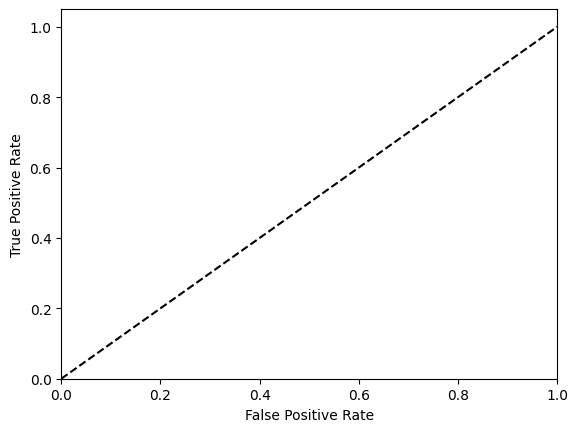

In [8]:
# print roc curve
plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % auc(fpr, tpr))
plt.plot([0, 1], [0, 1], 'k--')  # diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

In [ ]:
# overall accuracy, TPR, FPR
num_events = len(arrays['_label_'])
num_correct = np.sum(arrays['_label_'] == arrays['predicted_label'])
accuracy = num_correct / num_events


In [ ]:
print(arrays['_label_'])
#print(arrays['predicted_label'])
print(arrays['label_Hbb'])
print(arrays['score_label_Hbb'])

In [ ]:
# Getting the ROC curve for Hbb vs non-Hbb
from sklearn.metrics import confusion_matrix, roc_curve, auc
cnf_matrix = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cnf_matrix)

In [ ]:
def rejection(fpr, target_tpr, scores, labels):
    # Find the threshold that gives the target TPR
    idx = np.argmax(tpr >= target_tpr)
    threshold = thresholds[idx]
    # Calculate the rejection (1 / FPR) at this threshold
    fpr_at_threshold = fpr[idx]
    if fpr_at_threshold == 0:
        return float('inf')  # Infinite rejection if FPR is 0
    return 1.0 / fpr_at_threshold

In [ ]:
from sklearn.metrics import roc_curve

# rejection for each label (target TPR = 0.5 except for Hlvqq TPR = 0.99 and Tblv TPR = 0.995)
target_tprs = [0.5]*10
target_tprs[5] = 0.99  # Hlvqq
target_tprs[9] = 0.995 # Tblv
rejections = []

label_to_name = {
    0: 'QCD',
    1: 'Hbb',
    2: 'Hcc',
    3: 'Hgg',
    4: 'H4q',
    5: 'Hqql',
    6: 'Zqq',
    7: 'Wqq',
    8: 'Tbqq',
    9: 'Tbl'
}

for i in range(10):
    fpr, tpr, thresholds = roc_curve((y_true == i), scores[:,i])
    rej = rejection(fpr, target_tprs[i], scores[:,i], y_true)
    rejections.append(rej)
    print(f"Rejection for class {label_to_name[i]} at TPR={target_tprs[i]}: {rej:.2f}")